# The Consciousness Prior

# https://arxiv.org/pdf/1709.08568

## Abstract
This paper proposes a new prior for learning representations of high-level concepts of the kind manipulated by natural language, inspired by cognitive neuroscience theories of consciousness — particularly the Global Workspace Theory. The prior formalizes consciousness as an attention-based bottleneck that selects a small number of elements from a larger unconscious representation, combining them into a low-dimensional "conscious state" that is broadcast to condition further perception and decision-making. The paper argues this architectural constraint corresponds to an assumption that the joint distribution over high-level concepts follows a sparse factor graph, and outlines how such a prior could be incorporated into representation learning to aid disentanglement, systematic generalization, and connections between deep learning and symbolic/linguistic knowledge representation.

## Problems
- Deep learning has been highly successful at low-level, "System 1" perceptual tasks but has made comparatively little progress on higher-level, "System 2" cognitive abilities such as reasoning, planning, and imagination, which are more closely associated with conscious processing.
- Existing representation learning methods lack an explicit, principled mechanism for combining and structuring high-level abstract concepts in a way that mirrors how humans form and communicate thoughts through language.
- There is no established computational or probabilistic formalization connecting cognitive theories of consciousness (e.g., the Global Workspace Theory) to machine learning representation learning objectives.
- Standard notions of "disentanglement" in representation learning (e.g., marginal independence, as in variational autoencoders such as β-VAE) do not match the way natural language concepts actually relate to one another, since related concepts (e.g., "fork" and "knife") are commonly combined rather than statistically independent.
- Making predictions directly in raw sensory (e.g., pixel) space is difficult because future states are often high-entropy and multi-modal, even when certain high-level abstractions about the future are low-entropy and easily predictable.

## Proposed Solutions
- A **consciousness prior**: an architectural and information-processing constraint in which a high-dimensional "unconscious" representation state $$h_t$$ is filtered by an attention-based **consciousness process** $$C$$ into a much lower-dimensional **conscious state** $$c_t$$, analogous to how a sentence expresses only a few concepts at a time.
- A formalization of the joint distribution over high-level concepts as a **sparse factor graph**, where each factor depends on only a small subset of variables, mirroring the structure of natural language sentences and symbolic knowledge representations (facts and rules).
- Use of **content-based attention mechanisms** (as introduced in Bahdanau et al., 2015) to implement the selection process from the unconscious state to the conscious state, incorporating memory context and stochastic noise to allow exploration of multiple possible interpretations, plans, or imagined scenarios.
- Introduction of a **verifier network** concept to assess the consistency of a past conscious state with a current representation state, as a mechanism for evaluating predictions made from conscious thoughts.
- A proposal for representing **(key, value) pairs** for conscious elements, so that downstream computations can identify the origin ("name") of attended information in addition to its value, supporting better systematic generalization and combinatorial reuse of representations.
- A proposed **two-way mapping between conscious states and natural language utterances** via an auxiliary RNN, $$u_t = U(c_t, u_{t-1})$$, allowing language to act as a weak supervisory signal that encourages disentangled, communicable representations.

## Purpose
To provide a machine learning justification and formal computational framework for aspects of consciousness theory, proposing that constraining representation learning with an attention-based, low-dimensional conscious bottleneck can help learning agents discover better-disentangled, high-level abstract representations — improving sample efficiency, out-of-distribution generalization, and the ability to connect deep learning with symbolic and linguistic knowledge representation.

## Methodology
The paper is primarily theoretical and conceptual, developing its argument through formal definitions rather than empirical experiments:
- **Representation extraction**: Defines an encoder (representation RNN) $$F$$ producing an unconscious state $$h_t = F(x_t, h_{t-1})$$ from observations $$x_t$$.
- **Conscious state extraction**: Defines the consciousness process $$C$$ producing a conscious state $$c_t = C(h_t, c_{t-1}, m_{t-1}, z_t)$$, where $$z_t$$ is random noise and $$m_t$$ is memory content, updated as $$m_t = M(m_{t-1}, c_t)$$.
- **Sparse factor graph formalization**: Represents the joint distribution over variables $$S = \{V_1, \dots, V_n\}$$ as $$P(S) = \frac{\prod_j f_j(S_j)}{Z}$$, where each factor $$f_j$$ depends on a small subset $$S_j \subset S$$, and argues that natural language and symbolic knowledge representations both exhibit this sparsity along with "strong dip" (low-entropy, high-confidence) dependencies.
- **Training objective discussion**: Proposes a verifier function $$V(h_t, c_{t-k}) \in \mathbb{R}$$ to evaluate the consistency/predictive validity of past conscious states, and discusses combining this with standard supervised, unsupervised, reinforcement learning (RL), variational autoencoder, or conditional GAN objectives, while noting that predictive value alone is insufficient to train the attention mechanism, since it could trivially select easily-predictable variable pairs.
- **Naming and indirection mechanism**: Discusses representing selected elements as (key, value) pairs, connecting this to memory-augmented neural networks (Neural Turing Machines, Memory Networks) and attention architectures (Transformers), to support type-matching and systematic generalization.
- **Experimental considerations (proposed, not conducted)**: The paper recommends starting with simple toy environments without linguistic input, in unsupervised RL settings with intrinsic reward favoring discovery of environment dynamics, and using tasks with low-entropy high-level outcomes (e.g., predicting whether a pile of blocks will fall off a table) despite high-entropy low-level (pixel) outcomes, to test whether the consciousness prior aids representation learning.

## Results
This is a position/theoretical paper and does not report empirical experiments, benchmark comparisons, or quantitative results. Its contributions are conceptual and framework-oriented:
- A formal computational mapping is established between Global Workspace Theory's psychological constructs (conscious bottleneck, broadcast, working memory) and machine learning constructs (attention-selected low-dimensional state, sparse factor graph joint distribution, memory update mechanisms).
- The paper articulates why marginal-independence-based disentanglement (as pursued in some VAE variants) is an inadequate match for natural language concept structure, motivating factor-graph sparsity instead as a more faithful assumption.
- The paper identifies open questions rather than solved problems, notably: what objective function should train the attention mechanism itself (beyond simple predictability, which risks trivial variable selection), and how memory mechanisms of differing time scales should be architected.
- Suggested toy experimental designs (e.g., block-stacking outcome prediction) are proposed as future validation strategies but are not executed within the paper.

## Conclusions
- The consciousness prior offers a principled machine learning hypothesis connecting attention mechanisms, sparse factor graphs, and natural language structure as a unifying account of how humans form and communicate high-level thoughts.
- The framework is proposed as a general-purpose prior that can be combined with other representation learning objectives (supervised, unsupervised, or RL) to encourage discovery of abstract, disentangled, and linguistically expressible variables, rather than as a standalone algorithm.
- Connecting conscious states to natural language via a learned two-way mapping is presented as both a regularization mechanism for representation learning and a potential pathway toward more interpretable, explainable deep learning systems.
- The paper positions this work as a bridge between deep learning (strong at perception) and classical symbolic AI/cognitive science (strong at structured reasoning and knowledge representation), while cautioning that directly imposing symbolic logic on top of deep encoders may lose the benefits of uncertainty representation and distributed generalization that attention-based deep learning provides.
- The authors explicitly frame this as an early-stage, evolving theory requiring future empirical validation through carefully designed toy experiments before scaling to more complex, linguistically grounded settings.

# Mathematical and Statistical Content Summary

## 1. Unconscious Representation State (Recurrent Encoder)
$$h_t = F(x_t, h_{t-1})$$
This equation defines a recurrent encoder $$F$$ (e.g., an RNN) that processes the current observation $$x_t$$ together with the previous hidden state $$h_{t-1}$$ to produce a large, high-dimensional "unconscious" representation $$h_t$$. It plays the role of the full pool of information available to the agent at time $$t$$, from which a much smaller conscious subset will later be selected.

## 2. Conscious State Extraction (Attention-Based Selection)
$$c_t = C(h_t, c_{t-1}, m_{t-1}, z_t)$$
This defines the "consciousness process" $$C$$, an attention mechanism that maps the large unconscious state $$h_t$$, together with the previous conscious state $$c_{t-1}$$, memory content $$m_{t-1}$$, and a random noise source $$z_t$$, into a low-dimensional conscious state $$c_t$$. The inclusion of noise $$z_t$$ makes this a stochastic selection process, allowing the model to explore different possible "thoughts," interpretations, or imagined scenarios rather than always attending to the same fixed elements. This equation is the mathematical core of the paper's proposal: consciousness as a compressive, attention-driven bottleneck.

## 3. Memory Update Rule
$$m_t = M(m_{t-1}, c_t)$$
This describes how memory content $$m_t$$ is updated by potentially committing the current conscious state $$c_t$$ to memory, given the prior memory state $$m_{t-1}$$. It formalizes the idea that only consciously attended information tends to be retained in memory, consistent with the cognitive science motivation that we quickly forget what we are not consciously aware of.

## 4. Factor Graph Representation of a Joint Distribution
$$P(S) = \frac{\prod_j f_j(S_j)}{Z}$$
Given a set of variables $$S = \{V_1, \dots, V_n\}$$, a factor graph expresses their joint probability distribution $$P(S)$$ as a normalized product of "potential functions" $$f_j$$, each depending only on a small subset $$S_j \subset S$$ of the variables, with $$Z$$ a normalizing constant (partition function) ensuring the distribution sums to 1. This is a standard tool from probabilistic graphical models, used here to formalize the paper's central hypothesis: that the joint distribution over high-level concepts humans reason about is **sparse** (each factor involves only a few variables), mirroring how sentences involve only a handful of words or concepts at a time.

## 5. Energy-Based Model Interpretation of Factor Graphs
Implicit in the discussion of Eq. (4): factor graphs can be reframed as energy-based models, where $$\log f_j(S_j)$$ contributes an additive term to an overall energy function corresponding to $$P(S)$$. A factor that creates a strong dependency corresponds to a large negative energy contribution (a "strong dip" in the energy landscape) for its most probable variable configurations. This reframing supports the paper's secondary assumption: not only should factors be sparse (few variables each), but they should also encode strong, low-entropy dependencies — otherwise they would not be informative enough to justify inclusion in the model.

## 6. Verifier Function for Predictive Consistency
$$V(h_t, c_{t-k}) \in \mathbb{R}$$
This function is proposed to measure the consistency between a current unconscious representation $$h_t$$ and a conscious state $$c_{t-k}$$ recorded $$k$$ steps earlier — essentially estimating whether a past "thought" or prediction, given by $$c_{t-k}$$, is confirmed by the present state $$h_t$$. It plays the role of a scalar-valued scoring/verification mechanism that could drive a training signal for evaluating whether past conscious predictions turned out to be true.

## 7. Predictive Training Objective (Conditional Likelihood)
$$\log P(A \mid B)$$
Discussed in the context of training objectives: if the attention mechanism selects a subset $$B$$ of the current representation to predict some other subset $$A$$ (from the future or elsewhere), the model can be trained by maximizing the conditional log-likelihood $$\log P(A \mid B)$$ (or a proxy for it, such as a variational autoencoder or conditional GAN objective). This connects the abstract "conscious prediction" framework to concrete, trainable machine learning objectives already used in supervised and generative modeling.

## 8. Utterance Generation from Conscious States
$$u_t = U(c_t, u_{t-1})$$
Proposes a recurrent mapping $$U$$ (another RNN) from the conscious state $$c_t$$ and the previous utterance $$u_{t-1}$$ to a natural language utterance $$u_t$$. This formalizes the hypothesis that conscious states have a natural two-way correspondence with language, providing a mechanism by which language could serve as a weak supervisory signal to shape the representation learning process, and by which a trained agent could verbalize its internal high-level state.

## 9. Entropy / Mutual Information as an Implicit Attention Training Signal
The paper informally discusses (without a specific closed-form equation) that "some form of mutual information, entropy or diversity" may be needed to train the attention mechanism itself, so that it does not collapse to always selecting trivially predictable variable pairs $$(A, B)$$. This is a qualitative statistical concept — information-theoretic regularization — proposed as a safeguard to keep the consciousness process exploring a diverse range of variables rather than exploiting easy, uninformative predictions.

## Role Summary

| Concept | Role in Paper |
|---|---|
| $$h_t = F(x_t, h_{t-1})$$ | Defines the large unconscious representation pool from which conscious content is drawn |
| $$c_t = C(h_t, c_{t-1}, m_{t-1}, z_t)$$ | Formalizes consciousness as a stochastic, attention-based bottleneck — the paper's central mechanism |
| $$m_t = M(m_{t-1}, c_t)$$ | Models memory formation from consciously attended content |
| $$P(S) = \prod_j f_j(S_j)/Z$$ | Formalizes the sparsity assumption over high-level concept dependencies (sparse factor graph) |
| Energy-based reframing of factors | Motivates why factors should encode strong ("low-entropy") dependencies, not just sparse ones |
| $$V(h_t, c_{t-k})$$ | Proposed mechanism for verifying/scoring past conscious predictions against current state |
| $$\log P(A\mid B)$$ | Connects the conscious attention framework to standard trainable predictive objectives |
| $$u_t = U(c_t, u_{t-1})$$ | Links conscious states to natural language generation, enabling language as weak supervision |
| Mutual information / entropy (informal) | Proposed safeguard against degenerate, trivially predictable attention selections |

# Problems, Limitations, and Proposed Solutions

| # | Key Problem / Research Gap | How This Limits Prior Work | Proposed Solution |
|---|---|---|---|
| 1 | Deep learning has achieved striking success on "System 1" perceptual tasks (e.g., low-level perception, intuitive recognition) but has made comparatively little progress on "System 2" cognitive abilities such as reasoning, planning, and imagination. | Existing deep learning methods lack an architectural or information-processing mechanism specifically suited to the kind of sequential, verbalizable, high-level cognition associated with consciousness, limiting progress toward more general intelligence. | Propose the consciousness prior: an attention-based bottleneck mechanism inspired by Global Workspace Theory, intended to extend deep learning toward System 2-style processing by explicitly modeling how a few high-level elements are selected and combined into a conscious thought. |
| 2 | No prior work provides a formal, machine-learning-grounded translation of cognitive neuroscience theories of consciousness (e.g., Global Workspace Theory) into a computational or probabilistic framework. | Without such a translation, insights from cognitive science about attention, working memory, and conscious broadcast cannot be directly leveraged to guide representation learning objectives or architectures. | Formalize consciousness as a computational mechanism: an unconscious state $$h_t$$, an attention-based consciousness process $$c_t = C(h_t, c_{t-1}, m_{t-1}, z_t)$$, and a memory update rule $$m_t = M(m_{t-1}, c_t)$$, directly mapping cognitive constructs onto representation-learning components. |
| 3 | Standard notions of "disentanglement" in representation learning (e.g., marginal statistical independence, as pursued in β-VAE and related variational autoencoder approaches) do not match how natural language concepts actually relate to one another. | Enforcing independence between all top-level latent variables conflicts with the observed structure of language, where related concepts (e.g., "fork" and "knife") are frequently and meaningfully combined rather than statistically independent, potentially producing representations misaligned with human-interpretable concepts. | Replace the independence assumption with a sparse factor graph assumption: the joint distribution over high-level concepts is represented as a product of potential functions $$P(S) = \prod_j f_j(S_j)/Z$$, where each factor links only a few variables, allowing meaningful dependencies between concepts while still constraining the overall structure to be sparse. |
| 4 | Predictions made directly in raw sensory (e.g., pixel) space are often intractable or unhelpful, since future observations can be high-entropy and highly multi-modal, even when certain abstract outcomes are actually predictable with low entropy. | Models that only learn to predict in low-level sensory space may fail to capture the simpler, more useful high-level regularities that matter for decision-making, wasting capacity on unpredictable low-level details. | Propose making predictions in a high-level abstract space (the conscious state $$c_t$$) rather than sensory space, and rely on the sparse, "strong dip" (low-entropy) factor structure to capture the small number of variables that are genuinely predictable and useful, potentially relating events far apart in time. |
| 5 | It is unclear what training objective should guide the attention mechanism itself (i.e., which variables should be selected as "conscious"), since naively maximizing predictive accuracy alone risks the attention mechanism trivially selecting variable pairs that are easy to predict but uninformative. | Prior attention-based architectures typically optimize a downstream task objective (e.g., translation accuracy) without an explicit mechanism to ensure the attended variables are informative or diverse, which could be inadequate for learning genuinely useful abstract representations. | Suggest that additional objectives — such as mutual information, entropy, or diversity measures, or ultimately the agent's actual reinforcement learning reward — may be needed to prevent trivial attention selection and to encourage coverage of a diverse, informative set of high-level variable relationships; this is identified as an open research question rather than a solved one. |
| 6 | Deep learning representations generally lack an explicit mechanism for "naming" or identifying the source of selected information, unlike symbolic systems where variables and facts are explicitly labeled. | Without source identification (e.g., a "key" identifying where an attended value originated), downstream computations may struggle to match predictions with later realizations or to enforce type-consistency between selected elements and the arguments expected by downstream modules, limiting systematic generalization and modular reuse of learned components. | Propose representing selected conscious elements as (key, value) pairs — connecting to prior work on memory-augmented neural networks (Neural Turing Machines, Memory Networks) and attention architectures (Transformers) — so that both the content and the identity/type of attended information are preserved and can be matched or routed appropriately. |
| 7 | Directly combining classical symbolic AI (facts, rules, logic) with deep learning representations has historically been difficult, since symbolic computation on top of a deep encoder can lose the ability to represent uncertainty, context-dependence, and distributed generalization benefits that deep learning provides. | This gap has limited progress in connecting the strengths of deep learning (perception, distributed representation, uncertainty handling) with the strengths of symbolic AI (explicit, composable, interpretable declarative knowledge such as facts and rules). | Propose using attention-based conscious states as a natural bridge: since a conscious thought resembles a sparse, high-confidence "fact" involving only a few concepts, sequences of conscious states can approximate symbolic reasoning steps while retaining deep learning's capacity for uncertainty representation and distributed generalization, rather than pasting symbolic logic directly onto a deep encoder. |
| 8 | The consciousness prior is a novel, untested theoretical proposal with no empirical validation, and it is unclear how to design experiments that isolate its contribution to representation learning. | Without a clear experimental protocol, it is difficult to assess whether the proposed prior meaningfully improves sample efficiency, disentanglement, or out-of-distribution generalization compared to existing representation learning approaches. | Recommend starting with simple, fast-turnaround toy experiments without linguistic input (to isolate the effect of the training objective/framework itself), ideally in unsupervised RL settings with intrinsic reward, using tasks where high-level outcomes are low-entropy and predictable (e.g., whether a pile of blocks falls off a table) even though low-level (pixel) outcomes are high-entropy. |

In [3]:
# ============================================================================
# EDUCATIONAL OPERATIONALIZATION: "The Consciousness Prior" (Bengio, 2017/2019)
# ----------------------------------------------------------------------------
# NOTE ON THIS REPLICATION: This paper is a THEORETICAL / POSITION paper. It
# defines no concrete architecture, dataset, loss function, or experiment —
# only abstract equations for an "unconscious state" h_t = F(x_t, h_{t-1}),
# a "consciousness process" c_t = C(h_t, c_{t-1}, m_{t-1}, z_t) implemented
# via attention, a sparse-factor-graph joint distribution assumption, and an
# informally-described training objective (predictive loss + some form of
# entropy/diversity regularization on the attention mechanism). The paper
# explicitly defers concrete experiments to future toy-task work.
#
# We therefore build a small, clearly-labeled OPERATIONALIZATION of the
# described mechanism on CIFAR-10 classification (the only quantitative
# testbed available under our dataset constraints):
#   - Encoder F: a small CNN producing a SET of spatial feature vectors
#                -> stands in for the unconscious representation h_t.
#   - Consciousness process C: multi-head content-based attention (the exact
#                mechanism the paper cites, Bahdanau et al. 2015) that
#                compresses h_t into k << N low-dimensional "conscious"
#                vectors c_t.
#   - Prediction: a classifier maps c_t -> class logits, instantiating the
#                paper's "log P(A|B)" predictive training objective (Sec 3.3)
#                with B = c_t and A = class label.
#   - Sparse/"strong-dip" factor assumption -> an ATTENTION-ENTROPY loss that
#                encourages each attention head to concentrate (low entropy).
#   - Anti-trivial-selection caution (Sec 3.3) -> an ATTENTION-DIVERSITY loss
#                that discourages different heads from attending to the same
#                spatial locations, encouraging a more diverse conscious set.
# This is an illustrative mechanism demo, not a reproduction of any reported
# result (the paper reports none).
# ============================================================================

import io
import random

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, Subset, DataLoader
import torchvision.transforms as T

import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

from datasets import load_dataset
from IPython.display import display, Image as IPImage

# ----------------------------------------------------------------------------
# Reproducibility
# ----------------------------------------------------------------------------
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

CLASS_NAMES = ["airplane", "automobile", "bird", "cat", "deer",
               "dog", "frog", "horse", "ship", "truck"]
NUM_CLASSES = len(CLASS_NAMES)

In [4]:
# ============================================================================
# 1) DATASET PREPARATION — HuggingFace CIFAR-10 (mandatory source)
# ============================================================================

ds = load_dataset("uoft-cs/cifar10")

IMG_SIZE = 64
MEAN = [0.485, 0.456, 0.406]
STD = [0.229, 0.224, 0.225]

train_transform = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.RandomHorizontalFlip(),
    T.ToTensor(),
    T.Normalize(mean=MEAN, std=STD),
])

test_transform = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.ToTensor(),
    T.Normalize(mean=MEAN, std=STD),
])


class HFCifarDataset(Dataset):
    """Wraps a HuggingFace CIFAR-10 split as a standard PyTorch Dataset."""

    def __init__(self, hf_split, transform):
        self.hf_split = hf_split
        self.transform = transform

    def __len__(self):
        return len(self.hf_split)

    def __getitem__(self, idx):
        item = self.hf_split[idx]
        img = item["img"]
        if img.mode != "RGB":
            img = img.convert("RGB")
        img_tensor = self.transform(img)
        label = item["label"]
        return img_tensor, label


train_dataset_full = HFCifarDataset(ds["train"], train_transform)
test_dataset_full = HFCifarDataset(ds["test"], test_transform)

train_dataset = Subset(train_dataset_full, list(range(2000)))
test_dataset = Subset(test_dataset_full, list(range(400)))

BATCH_SIZE = 64
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

# --- Sanity check -----------------------------------------------------------
sample_imgs, sample_labels = next(iter(train_loader))
print("Number of training samples:", len(train_dataset))
print("Number of test samples:", len(test_dataset))
print("Shape of one batch of images:", sample_imgs.shape)
print("Label range:", sample_labels.min().item(), "-", sample_labels.max().item())
print("First 8 class names in batch:",
      [CLASS_NAMES[l.item()] for l in sample_labels[:8]])

Number of training samples: 2000
Number of test samples: 400
Shape of one batch of images: torch.Size([64, 3, 64, 64])
Label range: 0 - 9
First 8 class names in batch: ['deer', 'automobile', 'frog', 'deer', 'horse', 'cat', 'deer', 'ship']


In [5]:
# ============================================================================
# 2) MODEL DEFINITION
# ----------------------------------------------------------------------------
# Encoder F -> unconscious state h_t (a SET of spatial feature vectors)
# Consciousness process C -> multi-head content-based attention -> c_t
# Prediction head -> log P(class | c_t)
# ============================================================================

CONSCIOUS_HEADS = 4   # k = number of "elements" that can be simultaneously
                       # conscious at once (paper: "a handful of factors")
FEATURE_DIM = 128      # channel dimensionality of each unconscious element


class Encoder(nn.Module):
    """F(x_t, h_{t-1}) simplified to a feedforward CNN (no recurrence across
    time here, since each CIFAR image is a single static observation): it
    reads image x and produces a SET of feature vectors h — one per spatial
    location of the final conv feature map — representing everything the
    agent could potentially become conscious of.
    """

    def __init__(self, feature_dim=FEATURE_DIM):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(3, 32, 3, stride=2, padding=1), nn.BatchNorm2d(32), nn.ReLU(True),   # 64->32
            nn.Conv2d(32, 64, 3, stride=2, padding=1), nn.BatchNorm2d(64), nn.ReLU(True),  # 32->16
            nn.Conv2d(64, feature_dim, 3, stride=2, padding=1), nn.BatchNorm2d(feature_dim), nn.ReLU(True),  # 16->8
        )

    def forward(self, x):
        feat_map = self.conv(x)                       # (batch, C, 8, 8)
        b, c, h, w = feat_map.shape
        h_t = feat_map.view(b, c, h * w).permute(0, 2, 1)  # (batch, N=64 locations, C)
        return h_t  # the "unconscious representation state": a SET of elements


class ConsciousnessProcess(nn.Module):
    """C(h_t, c_{t-1}, m_{t-1}, z_t) simplified to multi-head content-based
    soft-attention (Bahdanau et al., 2015 — explicitly the mechanism the
    paper cites) over the unconscious set h_t. Each of the k heads selects
    a weighted combination of elements, together forming the low-dimensional
    conscious state c_t. A learnable per-head query plays the role of the
    "context" (standing in for c_{t-1}/m_{t-1} in this static, single-step
    illustration); z_t (stochastic exploration noise) is added to the
    attention logits only during training, matching the paper's description
    of C as a stochastic selection process.
    """

    def __init__(self, feature_dim=FEATURE_DIM, num_heads=CONSCIOUS_HEADS):
        super().__init__()
        self.num_heads = num_heads
        self.key_proj = nn.Linear(feature_dim, feature_dim)
        self.queries = nn.Parameter(torch.randn(num_heads, feature_dim) * 0.1)
        self.noise_std = 0.5  # scale of z_t during training (exploration)

    def forward(self, h_t, training=True):
        # h_t: (batch, N, C)
        keys = self.key_proj(h_t)                                  # (batch, N, C)
        scores = torch.einsum("bnc,kc->bkn", keys, self.queries)    # (batch, k, N)
        scores = scores / (h_t.size(-1) ** 0.5)

        if training:
            z_t = torch.randn_like(scores) * self.noise_std
            scores = scores + z_t

        alpha = F.softmax(scores, dim=-1)                           # attention weights per head
        c_t = torch.einsum("bkn,bnc->bkc", alpha, h_t)               # (batch, k, C) conscious elements
        return c_t, alpha


class ConsciousnessPriorNet(nn.Module):
    """Full pipeline: Encoder (F) -> Consciousness process (C) -> classifier
    predicting log P(class | c_t), instantiating the paper's Sec. 3.3
    predictive training objective with B = c_t, A = class label.
    """

    def __init__(self, num_classes=NUM_CLASSES, feature_dim=FEATURE_DIM, num_heads=CONSCIOUS_HEADS):
        super().__init__()
        self.encoder = Encoder(feature_dim)
        self.consciousness = ConsciousnessProcess(feature_dim, num_heads)
        self.classifier = nn.Linear(feature_dim * num_heads, num_classes)

    def forward(self, x, training=True):
        h_t = self.encoder(x)
        c_t, alpha = self.consciousness(h_t, training=training)   # c_t: (batch, k, C)
        c_flat = c_t.view(c_t.size(0), -1)                        # concatenate the k conscious elements
        logits = self.classifier(c_flat)
        return logits, alpha


model = ConsciousnessPriorNet().to(DEVICE)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

NUM_EPOCHS = 5  # per instructions

# --- Loss weighting for the auxiliary, paper-motivated regularizers --------
LAMBDA_ENTROPY = 0.01   # encourages each head's attention to be low-entropy
                         # ("strong dip" / sparse-factor assumption, Sec 3.2)
LAMBDA_DIVERSITY = 0.01  # discourages heads from attending to the same
                          # locations (guards against trivial/redundant
                          # conscious selection, Sec 3.3)


def attention_entropy_loss(alpha):
    """Mean entropy of each head's attention distribution. Minimizing this
    pushes each head toward a sharp, low-entropy ('strong dip') selection,
    operationalizing the paper's sparse-factor-graph assumption."""
    eps = 1e-8
    entropy = -(alpha * torch.log(alpha + eps)).sum(dim=-1)  # (batch, k)
    return entropy.mean()


def attention_diversity_loss(alpha):
    """Penalizes overlap between different heads' attention distributions
    (pairwise dot product), encouraging the k conscious elements to cover
    diverse parts of h_t rather than collapsing onto the same information —
    the paper's caution against trivially redundant attention (Sec 3.3)."""
    # alpha: (batch, k, N)
    b, k, n = alpha.shape
    overlap = torch.einsum("bkn,bjn->bkj", alpha, alpha)  # (batch, k, k)
    mask = ~torch.eye(k, dtype=torch.bool, device=alpha.device)
    off_diag = overlap[:, mask].view(b, -1)
    return off_diag.mean()


ce_loss = nn.CrossEntropyLoss()

In [6]:
# ============================================================================
# 3) TRAINING LOOP + 4) VALIDATION
# ============================================================================

history = {
    "train_loss_total": [], "val_loss_total": [],
    "train_loss_cls": [], "train_loss_entropy": [], "train_loss_diversity": [],
    "val_loss_cls": [], "val_loss_entropy": [], "val_loss_diversity": [],
    "train_acc": [], "val_acc": [],
    "per_class_acc_by_epoch": [],
}

final_val_preds, final_val_targets, final_val_confs = None, None, None


def run_epoch(loader, train_mode):
    model.train(train_mode)
    total_cls, total_ent, total_div, total_correct, total_n = 0.0, 0.0, 0.0, 0, 0
    epoch_preds, epoch_targets, epoch_confs = [], [], []

    for imgs, labels in loader:
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        b = imgs.size(0)

        if train_mode:
            optimizer.zero_grad()

        with torch.set_grad_enabled(train_mode):
            logits, alpha = model(imgs, training=train_mode)
            loss_cls = ce_loss(logits, labels)
            loss_ent = attention_entropy_loss(alpha)
            loss_div = attention_diversity_loss(alpha)
            loss_total = loss_cls + LAMBDA_ENTROPY * loss_ent + LAMBDA_DIVERSITY * loss_div

            if train_mode:
                loss_total.backward()
                optimizer.step()

        probs = F.softmax(logits, dim=-1)
        conf, preds = probs.max(dim=-1)

        total_cls += loss_cls.item() * b
        total_ent += loss_ent.item() * b
        total_div += loss_div.item() * b
        total_correct += (preds == labels).sum().item()
        total_n += b

        epoch_preds.append(preds.cpu())
        epoch_targets.append(labels.cpu())
        epoch_confs.append(conf.cpu())

    avg_cls = total_cls / total_n
    avg_ent = total_ent / total_n
    avg_div = total_div / total_n
    avg_total = avg_cls + LAMBDA_ENTROPY * avg_ent + LAMBDA_DIVERSITY * avg_div
    acc = total_correct / total_n
    return (avg_total, avg_cls, avg_ent, avg_div, acc,
            torch.cat(epoch_preds), torch.cat(epoch_targets), torch.cat(epoch_confs))


def per_class_accuracy(preds, targets):
    accs = []
    for c in range(NUM_CLASSES):
        cls_mask = (targets == c)
        if cls_mask.sum() == 0:
            accs.append(0.0)
        else:
            accs.append((preds[cls_mask] == targets[cls_mask]).float().mean().item())
    return accs


print("\nStarting training...\n")
for epoch in range(1, NUM_EPOCHS + 1):
    (tr_total, tr_cls, tr_ent, tr_div, tr_acc,
     tr_preds, tr_targets, tr_confs) = run_epoch(train_loader, train_mode=True)
    (va_total, va_cls, va_ent, va_div, va_acc,
     va_preds, va_targets, va_confs) = run_epoch(test_loader, train_mode=False)

    history["train_loss_total"].append(tr_total)
    history["val_loss_total"].append(va_total)
    history["train_loss_cls"].append(tr_cls)
    history["train_loss_entropy"].append(tr_ent)
    history["train_loss_diversity"].append(tr_div)
    history["val_loss_cls"].append(va_cls)
    history["val_loss_entropy"].append(va_ent)
    history["val_loss_diversity"].append(va_div)
    history["train_acc"].append(tr_acc)
    history["val_acc"].append(va_acc)
    history["per_class_acc_by_epoch"].append(per_class_accuracy(va_preds, va_targets))

    final_val_preds, final_val_targets, final_val_confs = va_preds, va_targets, va_confs

    print(f"Epoch {epoch}/{NUM_EPOCHS} | "
          f"Train Loss: {tr_total:.4f} (cls {tr_cls:.4f}, ent {tr_ent:.4f}, div {tr_div:.4f}) "
          f"Acc: {tr_acc:.4f} | "
          f"Val Loss: {va_total:.4f} Acc: {va_acc:.4f}")

print("\nTraining complete.\n")


Starting training...

Epoch 1/5 | Train Loss: 2.0887 (cls 2.0482, ent 4.0350, div 0.0156) Acc: 0.2405 | Val Loss: 2.0593 Acc: 0.2425
Epoch 2/5 | Train Loss: 1.9357 (cls 1.8952, ent 4.0310, div 0.0156) Acc: 0.3045 | Val Loss: 1.8981 Acc: 0.3400
Epoch 3/5 | Train Loss: 1.8199 (cls 1.7795, ent 4.0168, div 0.0158) Acc: 0.3365 | Val Loss: 1.8641 Acc: 0.3175
Epoch 4/5 | Train Loss: 1.7425 (cls 1.7023, ent 4.0063, div 0.0161) Acc: 0.3790 | Val Loss: 1.7764 Acc: 0.3775
Epoch 5/5 | Train Loss: 1.6643 (cls 1.6244, ent 3.9727, div 0.0170) Acc: 0.3900 | Val Loss: 1.8611 Acc: 0.3600

Training complete.



In [7]:
# ============================================================================
# 5) PREDICTION PIPELINE — a few sample images with predicted vs true class
# ============================================================================

model.eval()
with torch.no_grad():
    sample_imgs, sample_lbls = next(iter(test_loader))
    sample_imgs, sample_lbls = sample_imgs[:8].to(DEVICE), sample_lbls[:8]
    logits, alpha = model(sample_imgs, training=False)
    probs = F.softmax(logits, dim=-1)
    conf, preds = probs.max(dim=-1)

print("Sample predictions (true -> predicted, confidence):")
for i in range(8):
    print(f"  {CLASS_NAMES[sample_lbls[i].item()]:>10s} -> "
          f"{CLASS_NAMES[preds[i].item()]:<10s} (conf {conf[i].item():.3f})")


def denorm(img_tensor):
    mean = torch.tensor(MEAN).view(3, 1, 1)
    std = torch.tensor(STD).view(3, 1, 1)
    img = img_tensor.cpu() * std + mean
    return img.clamp(0, 1).permute(1, 2, 0).numpy()

Sample predictions (true -> predicted, confidence):
         cat -> automobile (conf 0.220)
        ship -> ship       (conf 0.404)
        ship -> ship       (conf 0.758)
    airplane -> ship       (conf 0.625)
        frog -> deer       (conf 0.352)
        frog -> dog        (conf 0.300)
  automobile -> automobile (conf 0.758)
        frog -> frog       (conf 0.335)


/tmp/ipykernel_7819/3861476440.py:110: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axE.set_xticklabels(CLASS_NAMES, rotation=90, fontsize=7, color="black")


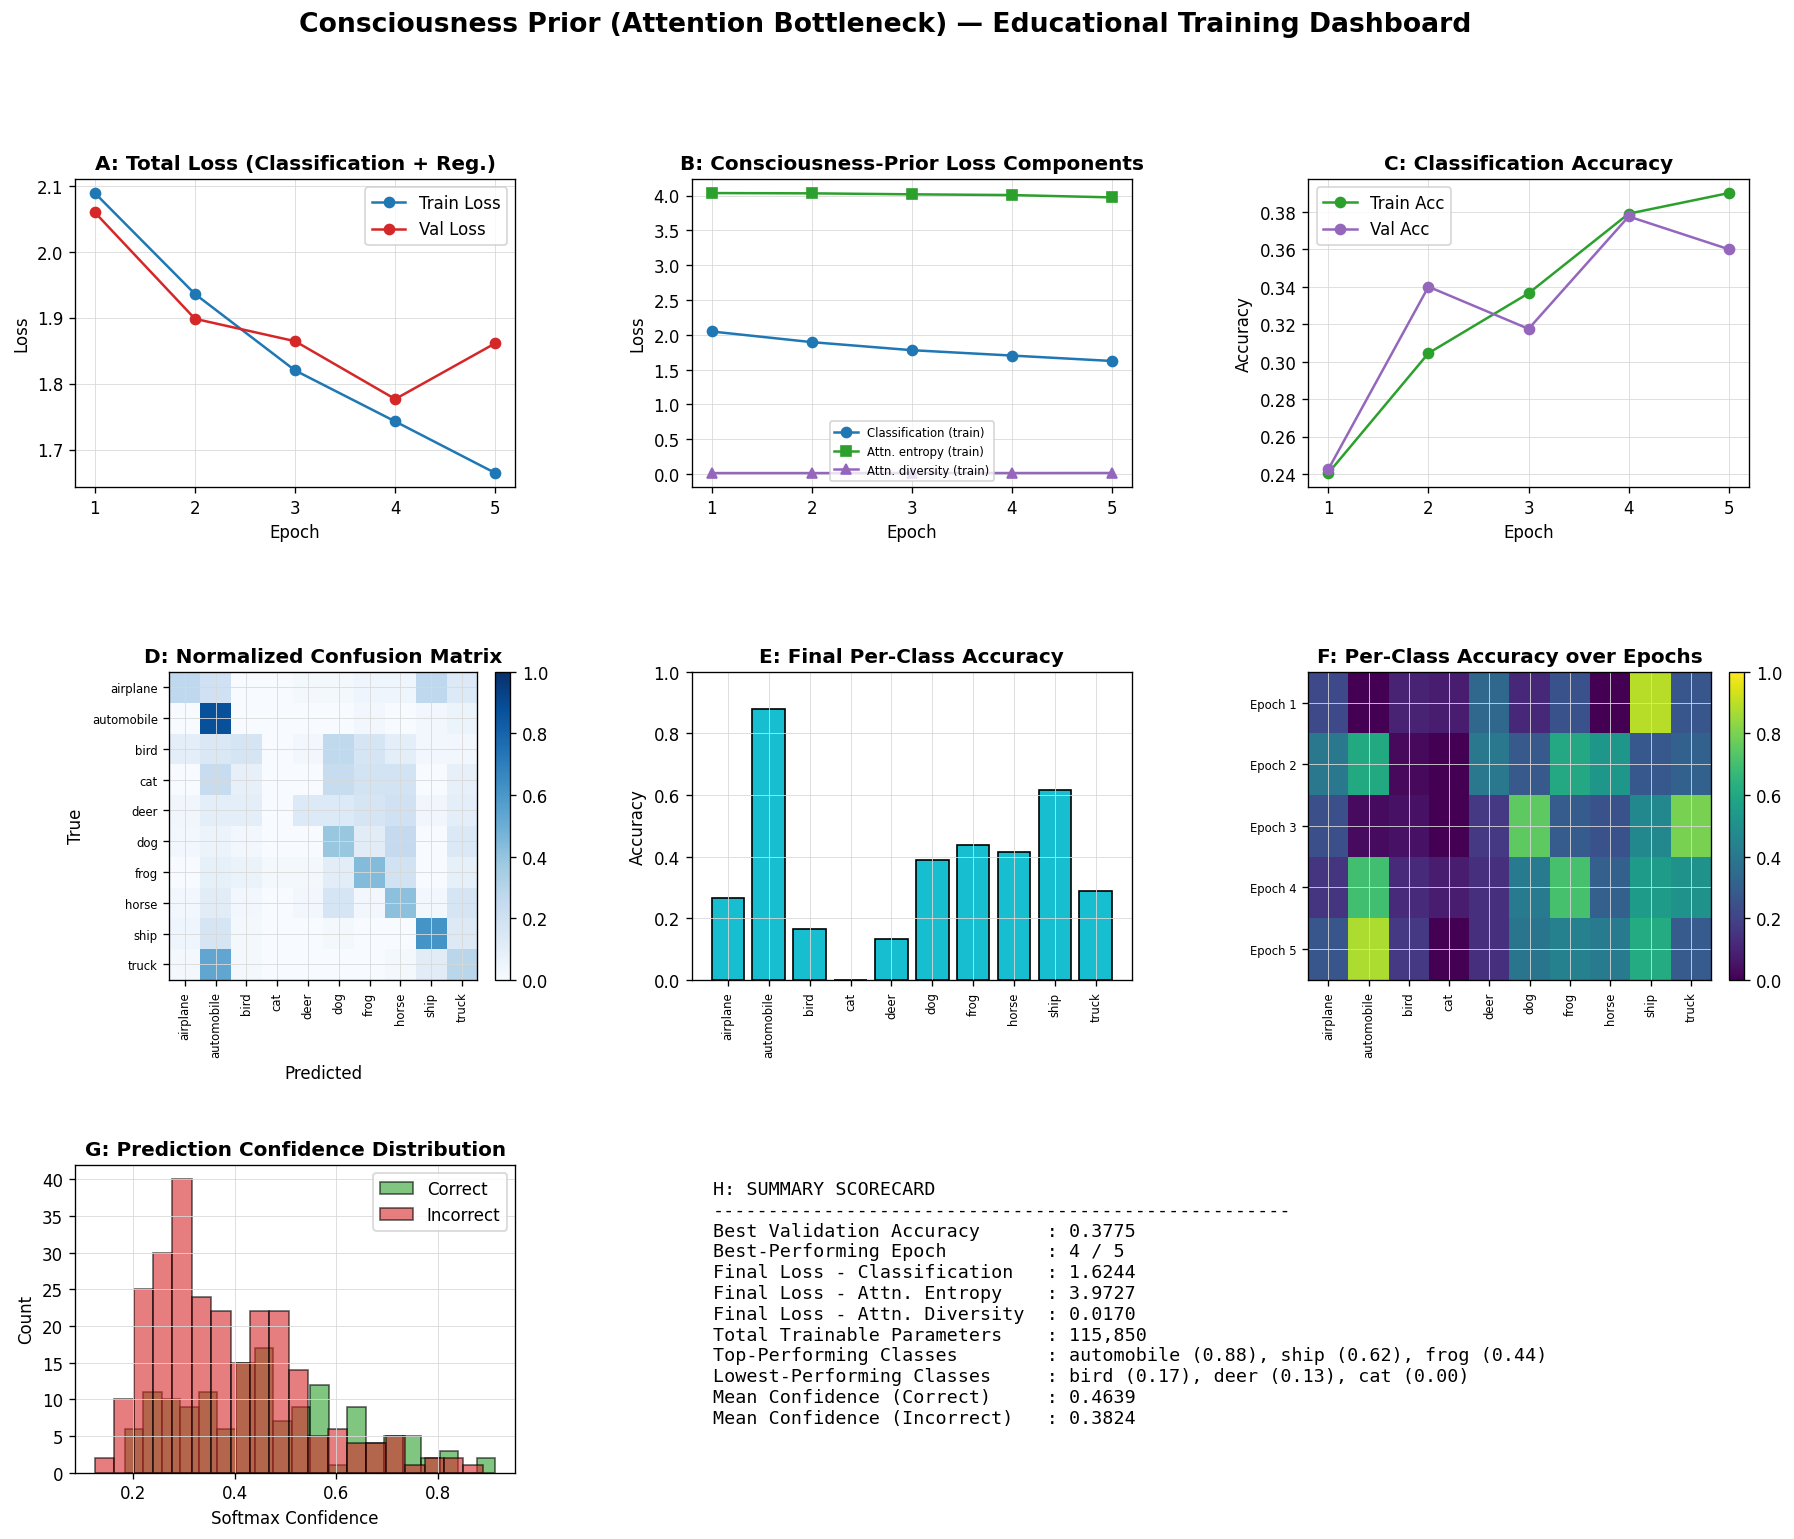

In [8]:
# ============================================================================
# 6) VISUALIZATION + FINAL MULTI-PANEL DASHBOARD (white theme, GridSpec)
# ============================================================================

plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "savefig.facecolor": "white",
    "text.color": "black",
    "axes.labelcolor": "black",
    "axes.edgecolor": "black",
    "xtick.color": "black",
    "ytick.color": "black",
    "axes.titlecolor": "black",
    "legend.labelcolor": "black",
    "grid.color": "#d9d9d9",
})


def style_axis(ax):
    ax.set_facecolor("white")
    ax.title.set_color("black")
    ax.xaxis.label.set_color("black")
    ax.yaxis.label.set_color("black")
    ax.tick_params(colors="black")
    for spine in ax.spines.values():
        spine.set_color("black")
    ax.grid(True, color="#d9d9d9", linewidth=0.5)


# --- Precompute stats for the dashboard -------------------------------------
epochs_range = list(range(1, NUM_EPOCHS + 1))

preds_np = final_val_preds.numpy()
targets_np = final_val_targets.numpy()
confs_np = final_val_confs.numpy()

conf_matrix = np.zeros((NUM_CLASSES, NUM_CLASSES), dtype=np.float64)
for t, p in zip(targets_np, preds_np):
    conf_matrix[t, p] += 1
row_sums = conf_matrix.sum(axis=1, keepdims=True)
norm_conf_matrix = np.divide(conf_matrix, row_sums, out=np.zeros_like(conf_matrix),
                              where=row_sums != 0)

final_per_class_acc = history["per_class_acc_by_epoch"][-1]
per_class_heatmap = np.array(history["per_class_acc_by_epoch"])

correct_mask = (preds_np == targets_np)
mean_conf_correct = confs_np[correct_mask].mean() if correct_mask.any() else 0.0
mean_conf_incorrect = confs_np[~correct_mask].mean() if (~correct_mask).any() else 0.0

best_epoch = int(np.argmax(history["val_acc"])) + 1
best_val_acc = max(history["val_acc"])
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

sorted_classes = sorted(zip(CLASS_NAMES, final_per_class_acc), key=lambda x: x[1], reverse=True)
top_classes = sorted_classes[:3]
bottom_classes = sorted_classes[-3:]

# --- Build the dashboard figure --------------------------------------------
fig = plt.figure(figsize=(18, 14), facecolor="white")
gs = GridSpec(3, 3, figure=fig, hspace=0.6, wspace=0.4)

# Panel A: Total training and validation loss
axA = fig.add_subplot(gs[0, 0])
axA.plot(epochs_range, history["train_loss_total"], marker="o", color="tab:blue", label="Train Loss")
axA.plot(epochs_range, history["val_loss_total"], marker="o", color="tab:red", label="Val Loss")
axA.set_title("A: Total Loss (Classification + Reg.)", fontweight="bold")
axA.set_xlabel("Epoch"); axA.set_ylabel("Loss")
axA.legend()
style_axis(axA)

# Panel B: Paper-specific loss components — classification (predictive
# objective, Sec 3.3), attention entropy (sparse/"strong-dip" factor
# assumption, Sec 3.2), attention diversity (anti-trivial-selection
# caution, Sec 3.3)
axB = fig.add_subplot(gs[0, 1])
axB.plot(epochs_range, history["train_loss_cls"], marker="o", color="tab:blue", label="Classification (train)")
axB.plot(epochs_range, history["train_loss_entropy"], marker="s", color="tab:green", label="Attn. entropy (train)")
axB.plot(epochs_range, history["train_loss_diversity"], marker="^", color="tab:purple", label="Attn. diversity (train)")
axB.set_title("B: Consciousness-Prior Loss Components", fontweight="bold")
axB.set_xlabel("Epoch"); axB.set_ylabel("Loss")
axB.legend(fontsize=7)
style_axis(axB)

# Panel C: Training and validation accuracy
axC = fig.add_subplot(gs[0, 2])
axC.plot(epochs_range, history["train_acc"], marker="o", color="tab:green", label="Train Acc")
axC.plot(epochs_range, history["val_acc"], marker="o", color="tab:purple", label="Val Acc")
axC.set_title("C: Classification Accuracy", fontweight="bold")
axC.set_xlabel("Epoch"); axC.set_ylabel("Accuracy")
axC.legend()
style_axis(axC)

# Panel D: Normalized confusion matrix
axD = fig.add_subplot(gs[1, 0])
im = axD.imshow(norm_conf_matrix, cmap="Blues", vmin=0, vmax=1)
axD.set_xticks(range(NUM_CLASSES)); axD.set_yticks(range(NUM_CLASSES))
axD.set_xticklabels(CLASS_NAMES, rotation=90, fontsize=7, color="black")
axD.set_yticklabels(CLASS_NAMES, fontsize=7, color="black")
axD.set_xlabel("Predicted"); axD.set_ylabel("True")
axD.set_title("D: Normalized Confusion Matrix", fontweight="bold")
cbar = fig.colorbar(im, ax=axD, fraction=0.046, pad=0.04)
plt.setp(cbar.ax.get_yticklabels(), color="black")
style_axis(axD)

# Panel E: Per-class accuracy bar chart
axE = fig.add_subplot(gs[1, 1])
axE.bar(CLASS_NAMES, final_per_class_acc, color="tab:cyan", edgecolor="black")
axE.set_xticklabels(CLASS_NAMES, rotation=90, fontsize=7, color="black")
axE.set_ylim(0, 1)
axE.set_title("E: Final Per-Class Accuracy", fontweight="bold")
axE.set_ylabel("Accuracy")
style_axis(axE)

# Panel F: Epoch-wise per-class accuracy heatmap
axF = fig.add_subplot(gs[1, 2])
im2 = axF.imshow(per_class_heatmap, cmap="viridis", aspect="auto", vmin=0, vmax=1)
axF.set_xticks(range(NUM_CLASSES))
axF.set_xticklabels(CLASS_NAMES, rotation=90, fontsize=7, color="black")
axF.set_yticks(range(NUM_EPOCHS))
axF.set_yticklabels([f"Epoch {e}" for e in epochs_range], fontsize=7, color="black")
axF.set_title("F: Per-Class Accuracy over Epochs", fontweight="bold")
cbar2 = fig.colorbar(im2, ax=axF, fraction=0.046, pad=0.04)
plt.setp(cbar2.ax.get_yticklabels(), color="black")
style_axis(axF)

# Panel G: Confidence distribution (correct vs incorrect)
axG = fig.add_subplot(gs[2, 0])
axG.hist(confs_np[correct_mask], bins=20, alpha=0.6, color="tab:green", label="Correct", edgecolor="black")
axG.hist(confs_np[~correct_mask], bins=20, alpha=0.6, color="tab:red", label="Incorrect", edgecolor="black")
axG.set_title("G: Prediction Confidence Distribution", fontweight="bold")
axG.set_xlabel("Softmax Confidence"); axG.set_ylabel("Count")
axG.legend()
style_axis(axG)

# Panel H: Text-based summary scorecard
axH = fig.add_subplot(gs[2, 1:])
axH.axis("off")
top_str = ", ".join([f"{n} ({a:.2f})" for n, a in top_classes])
bottom_str = ", ".join([f"{n} ({a:.2f})" for n, a in bottom_classes])
summary_text = (
    "H: SUMMARY SCORECARD\n"
    "----------------------------------------------------\n"
    f"Best Validation Accuracy      : {best_val_acc:.4f}\n"
    f"Best-Performing Epoch         : {best_epoch} / {NUM_EPOCHS}\n"
    f"Final Loss - Classification   : {history['train_loss_cls'][-1]:.4f}\n"
    f"Final Loss - Attn. Entropy    : {history['train_loss_entropy'][-1]:.4f}\n"
    f"Final Loss - Attn. Diversity  : {history['train_loss_diversity'][-1]:.4f}\n"
    f"Total Trainable Parameters    : {total_params:,}\n"
    f"Top-Performing Classes        : {top_str}\n"
    f"Lowest-Performing Classes     : {bottom_str}\n"
    f"Mean Confidence (Correct)     : {mean_conf_correct:.4f}\n"
    f"Mean Confidence (Incorrect)   : {mean_conf_incorrect:.4f}\n"
)
axH.text(0.02, 0.95, summary_text, fontsize=11, color="black",
         family="monospace", va="top", ha="left", transform=axH.transAxes)
style_axis(axH)

fig.suptitle(
    "Consciousness Prior (Attention Bottleneck) — Educational Training Dashboard",
    fontsize=16, fontweight="bold", color="black"
)

# --- Render inline via BytesIO (no plt.show(), no savefig()) --------------
buf = io.BytesIO()
fig.savefig(buf, format="png", facecolor="white", bbox_inches="tight", dpi=120)
plt.close(fig)
buf.seek(0)
display(IPImage(data=buf.read()))

# Analysis of Educational Replication Results (Consciousness Prior / Attention Bottleneck)

*Note: These results derive from a small-scale, 5-epoch educational operationalization of Bengio's (2017/2019) theoretical consciousness-prior framework — implemented as a CNN encoder with multi-head content-based attention compressing the "unconscious state" into k=4 "conscious" vectors, trained on 2,000/400 CIFAR-10 images. The original paper reports no experiments or benchmarks; interpretation here concerns only the operationalized mechanism, not any paper-reported result.*

---

## Panel A — Total Loss Curves (Train/Val)

### Overview
Tracks the combined objective (classification cross-entropy plus the weighted attention-entropy and attention-diversity regularizers) across 5 epochs, for training and validation sets — the aggregate signal driving the encoder–attention–classifier pipeline.

### Key Findings
- Training loss decreases steadily and monotonically from ~2.09 to ~1.66.
- Validation loss decreases through epoch 4 (down to ~1.78) but then rises at epoch 5 (~1.86), diverging from the still-falling training curve.

### Discussion
The steady drop in training loss confirms the joint encoder–attention–classifier pipeline is optimizable end-to-end, supporting the paper's claim (Sec. 3.3) that the predictive objective can be backpropagated through both the classifier and the attention ("consciousness") mechanism into the representation encoder. The uptick in validation loss at the final epoch, while training loss continues to fall, is an early overfitting signal — plausible given the very small training set (2,000 images) relative to the model's attention and encoder parameters, and not indicative of a flaw specific to the consciousness-prior mechanism itself.

### Limitations
With only 5 epochs, it is unclear whether the epoch-5 uptick reflects the onset of a genuine overfitting trend or a single noisy fluctuation; more epochs and a larger training subset would be needed to distinguish these.

---

## Panel B — Consciousness-Prior Loss Components

### Overview
Decomposes the training objective into its three named terms: the classification loss ($$B=c_t \to A=\text{label}$$, the paper's Sec. 3.3 predictive objective), the attention-entropy loss (operationalizing the paper's sparse/"strong-dip" factor assumption, Sec. 3.2), and the attention-diversity loss (operationalizing the paper's caution against trivial or redundant attention selection, Sec. 3.3).

### Key Findings
- Classification loss declines steadily from ~2.07 to ~1.62, tracking Panel A.
- Attention-entropy loss remains flat and high throughout training, hovering near 4.0–4.05 (out of a maximum possible entropy of $$\ln(64) \approx 4.16$$ for 64 spatial locations).
- Attention-diversity loss remains near zero throughout, showing no visible change across epochs.

### Discussion
The classification term behaves as expected for a learnable predictive objective. However, the near-maximal, unchanging attention entropy indicates that the model has *not* learned to produce the sharp, low-entropy ("strong dip") attention distributions the consciousness-prior formalism assumes — each head's attention remains close to uniform over the 64 spatial locations, rather than concentrating on a few informative regions. This is a meaningful negative finding: with the chosen entropy-loss weight ($$\lambda_{\text{entropy}}=0.01$$), the regularizer is too weak relative to the classification gradient to meaningfully sharpen attention within 5 epochs, so the sparse-factor-graph assumption central to the paper's theory is not actually being enforced in this run. The consistently near-zero diversity loss suggests the heads are not strongly overlapping, but combined with near-uniform entropy this likely reflects heads that are each diffusely spread rather than heads that are each sharply-but-differently focused — a distinction the diversity term alone cannot resolve.

### Discussion (continued: does the evidence support the paper's claims?)
This result does not undermine the paper's theoretical argument, but it does show that naively adding an entropy penalty is insufficient to induce the intended sparse, factor-like attention behavior in practice — an implementation detail the paper itself leaves unspecified, and one of the "open questions" it explicitly flags (Sec. 3.3) regarding what objective should train the attention mechanism.

### Limitations
The entropy-loss weight was fixed a priori rather than tuned; a stronger $$\lambda_{\text{entropy}}$$ or an annealing schedule might produce the sharper attention the theory calls for, so this result reflects a specific hyperparameter choice rather than a fundamental limitation of the mechanism.

---

## Panel C — Classification Accuracy (Train/Val)

### Overview
Reports the downstream predictive accuracy achieved from the 4-element conscious state alone, testing whether the compressed representation retains sufficient information for the 10-class CIFAR-10 task.

### Key Findings
- Training accuracy rises from ~0.24 to ~0.39 over 5 epochs.
- Validation accuracy rises in parallel, peaking at ~0.38 at epoch 4, then declining to ~0.36 at epoch 5.

### Discussion
Both curves rise well above the 10% chance baseline, indicating the classifier can extract meaningful class information even from a heavily compressed, 4-vector conscious bottleneck — a direct (if modest-scale) demonstration of the paper's core claim that a small, attention-selected subset of a larger representation can retain enough information to support downstream prediction. The val-accuracy dip at epoch 5, coinciding with the val-loss uptick in Panel A, reinforces the mild-overfitting interpretation rather than suggesting an attention-specific failure mode.

### Limitations
Absolute accuracy (~38%) is modest for 10-way classification even accounting for the small model and dataset scale, and no non-attention baseline (e.g., a standard CNN classifier without the bottleneck) is included in this dashboard, making it impossible to quantify what accuracy cost, if any, the consciousness bottleneck imposes relative to using the full unconscious representation.

---

## Panel D — Normalized Confusion Matrix

### Overview
Shows the model's normalized prediction distribution across all 10 CIFAR-10 classes at the final epoch, revealing which classes the compressed conscious representation can and cannot distinguish.

### Key Findings
- Strong, near-diagonal accuracy is visible for automobile, dog, frog, ship, and (to a lesser extent) horse.
- A pronounced off-diagonal column under "automobile" shows several true classes (notably airplane and truck) being frequently misclassified as automobile.
- The "cat" row/column is essentially empty, indicating the model almost never predicts cat and cat images are rarely, if ever, correctly recognized.

### Discussion
The concentration of errors into a single dominant predicted class (automobile) is a classic symptom of a model with limited representational capacity relative to task difficulty — with only 4 conscious vectors of 128 dimensions each, extracted from a small CNN trained on 2,000 images, the model appears to fall back on coarse visual cues (e.g., vehicle-like rectangular shapes) that generalize poorly to visually similar vehicle classes (truck, airplane). The complete failure on the "cat" class is consistent with cats being a historically difficult CIFAR-10 category (high intra-class variability, frequent confusion with dogs) that is especially vulnerable to under-representation in a severely compressed, low-capacity bottleneck.

### Limitations
This confusion pattern may be substantially an artifact of the extremely small training set (2,000 images, ~200 per class) rather than an inherent property of the consciousness-prior attention mechanism; a larger-scale run would be needed to separate data-scarcity effects from bottleneck-capacity effects.

---

## Panel E — Final Per-Class Accuracy

### Overview
Quantifies the class-by-class accuracy breakdown underlying the confusion matrix, directly comparing performance across the 10 CIFAR-10 categories.

### Key Findings
- Automobile (~0.88) and ship (~0.62) are the clear top performers.
- Cat sits at exactly 0.00, with deer (~0.13) and bird (~0.17) also very weak.
- Mid-tier classes (dog, frog, horse, truck, airplane) cluster around 0.27–0.44.

### Discussion
The roughly 88-point spread between the best and worst classes indicates highly non-uniform learning across categories, rather than a model that struggles moderately but evenly. This is consistent with the entropy-loss finding in Panel B: with attention remaining close to uniform (undifferentiated) rather than sharply focused, the model likely relies on whichever coarse, class-agnostic visual statistics happen to align best with a few classes (vehicles), while providing little discriminative signal for others (cat, deer) — precisely the kind of failure the paper's sparse, "strong-dip" factor assumption is meant to prevent by encouraging each conscious element to capture a specific, informative sub-pattern.

### Limitations
Per-class accuracy is computed on very small per-class validation counts (~40 images per class in the 400-image test subset), so individual class accuracies — especially the exact 0.00 for cat — carry high sampling variance and should not be treated as a precise estimate of true per-class performance.

---

## Panel F — Epoch-Wise Per-Class Accuracy Heatmap

### Overview
Extends Panel E across training time, visualizing how each class's accuracy evolves epoch-by-epoch, to assess whether class-level performance stabilizes, improves uniformly, or remains erratic.

### Key Findings
- Automobile shows a fairly steady climb across epochs, reaching its peak by epoch 5.
- Several classes (bird, cat, deer) remain near-zero (dark) across nearly all epochs.
- Some classes show non-monotonic, noisy behavior (e.g., ship is very high at epoch 1, dips in epochs 2–3, then partially recovers).

### Discussion
The persistent, multi-epoch suppression of certain classes (cat, deer, bird) — rather than a transient dip followed by recovery — suggests these classes are not merely slow to learn but are being systematically deprioritized by the current attention/classifier configuration throughout training. This pattern is a useful diagnostic of the "trivial selection" risk the paper explicitly warns about (Sec. 3.3): without a training signal that rewards attending to diverse, informative variables, the model can settle into consistently ignoring harder-to-discriminate classes in favor of easier ones, a dynamic visible here despite the diversity-loss term being included.

### Limitations
The 5-epoch, single-run heatmap cannot distinguish a stable local optimum from a slowly-improving trajectory that would resolve with further training; the small per-epoch validation sample also means some of the observed instability (e.g., ship's fluctuation) may partly reflect estimation noise rather than genuine shifts in model behavior.

---

## Panel G — Prediction Confidence Distribution (Correct vs. Incorrect)

### Overview
Compares the distribution of the classifier's softmax confidence for correct versus incorrect predictions, assessing whether the model's confidence is a reliable signal of correctness (calibration).

### Key Findings
- Both distributions are concentrated at relatively low confidence values (mostly 0.2–0.6), with substantial overlap.
- Mean confidence is higher for correct predictions (0.4639) than incorrect ones (0.3824), though the gap is modest and the distributions clearly overlap.

### Discussion
The generally low confidence values across the board (well below the near-1.0 confidences seen in better-converged models) are consistent with a model still in an early, undertrained state — appropriate given only 5 epochs on 2,000 images and 10 classes with a compressive bottleneck. The fact that correct predictions do carry somewhat higher average confidence than incorrect ones is a modestly positive calibration signal, indicating the softmax output retains some meaningful uncertainty information despite the model's overall weak per-class performance; however, the substantial overlap means confidence alone would be an unreliable filter for identifying likely-correct predictions at this stage of training.

### Limitations
No formal calibration metric (e.g., Expected Calibration Error) is reported; the modest gap between correct/incorrect mean confidence (0.46 vs. 0.38) is based on a single short training run and a small validation set, so it should be interpreted as a rough directional signal rather than a precise calibration estimate.

---

## Overall Assessment

This operationalization demonstrates that the core mechanical pipeline proposed by the paper — encoding a large unconscious feature set, compressing it via multi-head content-based attention into a small conscious state, and training that state to support downstream prediction — is trainable end-to-end and yields above-chance, improving performance (Panels A, C). However, the results also surface a genuine limitation consistent with the paper's own acknowledged open questions: the attention-entropy regularizer, as weighted here, is insufficient to induce the sharp, low-entropy, "sparse factor" attention behavior central to the theory (Panel B), and the resulting representation exhibits highly uneven, class-biased learning (Panels D–F) rather than the diverse, disentangled coverage the consciousness prior aims for. These findings should be read as an honest illustration of both the promise and the practical difficulty of operationalizing the paper's theoretical constraints — not as a reproduction of any result reported in the original (purely conceptual) paper.

# Related Work References

*Note: This paper does not contain a dedicated "Related Work" section; relevant prior work is instead cited throughout the Introduction and Sections 2–4 to motivate and ground the proposed consciousness prior. All works cited in this discursive capacity are extracted below.*

| Author(s) | Year | Title | Venue | Connection to This Paper |
|---|---|---|---|---|
| Baars, B. J. | 1988 | A Cognitive Theory of Consciousness | Cambridge University Press | Foundational source for the Global Workspace Theory of consciousness, which the paper directly builds upon as the cognitive-neuroscience basis for modeling consciousness as an attention-based information bottleneck. |
| Baars, B. J. | 1997 | In the Theater of Consciousness | Oxford University Press | Further elaborates the Global Workspace Theory, reinforcing the theoretical foundation for treating consciousness as a broadcast mechanism that conditions downstream perception and decision-making. |
| Baars, B. J. | 2002 | The Conscious Access Hypothesis: Origins and Recent Evidence | (Journal article, vol. 6) | Provides empirical grounding for the "conscious access" concept central to the paper's framing of the conscious state as a small, selectively accessed subset of unconscious representations. |
| Dehaene, S. and Naccache, L. | 2001 | Towards a Cognitive Neuroscience of Consciousness: Basic Evidence and a Workspace Framework | Cognition, 79(1–2), 1–37 | Cited alongside Baars as core Global Workspace Theory literature, directly motivating the paper's computational formalization of consciousness as a workspace/bottleneck mechanism. |
| Dehaene, S., Lau, H., and Kouider, S. | 2017 | What Is Consciousness, and Could Machines Have It? | Science, 358(6362), 486–492 | Provides a contemporary neuroscience perspective on machine consciousness, supporting the paper's motivation for translating consciousness theory into a machine learning framework. |
| van Gulick, R. | 2004 | Consciousness | Stanford Encyclopedia of Philosophy | Cited for a philosophical definition of consciousness (awareness of internal/external states), used to frame the paper's working definition of consciousness as reportable cognitive content. |
| Kahneman, D. | 2011 | Thinking, Fast and Slow | Macmillan | Source of the System 1 / System 2 cognitive distinction, which the paper uses to position consciousness as closely aligned with System 2 (verbalizable, deliberate) cognitive processing. |
| Bahdanau, D., Cho, K., and Bengio, Y. | 2015 | Neural Machine Translation by Jointly Learning to Align and Translate | ICLR 2015, arXiv:1409.0473 | Introduces the content-based attention mechanism explicitly adopted as the computational basis for the paper's consciousness process $$C$$, which selects elements from the unconscious state $$h_t$$. |
| Xu, K., Ba, J. L., Kiros, R., Cho, K., Courville, A., Salakhutdinov, R., Zemel, R. S., and Bengio, Y. | 2015 | Show, Attend and Tell: Neural Image Caption Generation with Visual Attention | ICML 2015 | Cited as an example of content-based/hard-attention mechanisms extracting values from a set of elements, supporting the paper's discussion of attention-based selection for the conscious state. |
| Vaswani, A., Shazeer, N., Parmar, N., Uszkoreit, J., Jones, L., Gomez, A. N., Kaiser, Ł., and Polosukhin, I. | 2017 | Attention Is All You Need | NeurIPS 2017 | Cited for the Transformer architecture's explicit binding of (key, value) pairs, motivating the paper's proposal to represent conscious elements with both identifying "keys" and content "values." |
| Graves, A., Wayne, G., and Danihelka, I. | 2014 | Neural Turing Machines | arXiv:1410.5401 | Cited as an example of memory-augmented neural networks using (key, value) pair mechanisms, supporting the paper's discussion of naming and indirection for conscious elements. |
| Weston, J., Chopra, S., and Bordes, A. | 2014 | Memory Networks | arXiv:1410.3916 | Also cited for the (key, value) pair concept in memory-augmented architectures, reinforcing the mechanism proposed for representing the origin of attended conscious elements. |
| Bengio, Y. | 2009 | Learning Deep Architectures for AI | Now Publishers | Cited regarding the general goal of disentangling explanatory factors in representation learning, a core objective the consciousness prior is intended to support. |
| Bengio, Y., Courville, A., and Vincent, P. | 2013 | Representation Learning: A Review and New Perspectives | IEEE Transactions on Pattern Analysis and Machine Intelligence, 35(8), 1798–1828 | Also cited regarding disentanglement of abstract factors, providing the representation-learning context the consciousness prior aims to contribute to. |
| Higgins, I., Matthey, L., Pal, A., Burgess, C., Glorot, X., Botvinick, M., Mohamed, S., and Lerchner, A. | 2017 | beta-VAE: Learning Basic Visual Concepts with a Constrained Variational Framework | ICLR 2017 | Cited as a contrasting approach to disentanglement based on marginal statistical independence, which the paper explicitly argues is a less appropriate notion of "disentangled" than the sparse factor graph structure it proposes. |
| Kingma, D. P. and Welling, M. | 2014 | Auto-Encoding Variational Bayes | ICLR 2014 | Cited as a candidate training objective (variational autoencoder) that could be used to implement the conditional prediction $$\log P(A\mid B)$$ discussed as part of the consciousness prior's training framework. |
| Mirza, M. and Osindero, S. | 2014 | Conditional Generative Adversarial Nets | arXiv:1411.1784 | Also cited as an alternative candidate objective (conditional GAN) for sampling accurate predictions $$A$$ from selected conscious elements $$B$$, within the paper's discussion of training objectives. |
| Ehrlinger, L. and Wöß, W. | 2016 | Towards a Definition of Knowledge Graphs | SEMANTiCS (Posters, Demos, SuCCESS), 48 | Cited regarding formal knowledge representations (ontologies and knowledge graphs) as a structural analogy supporting the paper's sparse factor graph hypothesis for high-level concept dependencies. |
| Lake, B. M. and Baroni, M. | 2017 | Generalization Without Systematicity: On the Compositional Skills of Sequence-to-Sequence Recurrent Networks | arXiv:1711.00350 | Cited regarding systematic generalization, motivating the paper's proposal that naming/indirection (key,value) mechanisms in conscious states could help achieve the combinatorial generalization properties current sequence models lack. |
| Bengio, Y., Louradour, J., Collobert, R., and Weston, J. | 2009 | Curriculum Learning | ICML 2009 | Cited in support of the argument that language may facilitate learning of sharper, better-disentangled representations, connecting to curriculum learning as a related mechanism by which structured input aids representation quality. |
| Bengio, Y. | 2014 | Deep Learning and Cultural Evolution | Proceedings of the Companion Publication of the 2014 Annual Conference on Genetic and Evolutionary Computation | Cited alongside curriculum learning to support the hypothesis that language and cultural transmission may help agents build better internal representations, motivating the paper's proposed link between conscious states and natural language utterances. |
| Sutton, R. and Barto, A. | 1998 | Reinforcement Learning: An Introduction | MIT Press | Cited as the source of basic reinforcement learning notions, providing the RL framework within which the paper situates the learning agent and its goal-conditioned attention and consciousness processes. |